# Analysis of 01DirAM Predicted Conditions vs Observed Correlations

Compares simulated correlations from the **NPE-predicted 01DirAM condition** against observed data.

The simulation is bivariate with two independent univariate Direct AM models:
- **Trait 1 (AE model)** — Direct AM, no vertical transmission, no social homogamy (`am11=0.3343`)
- **Trait 2 (AFE model)** — Direct AM, with vertical transmission (`f22=0.0111`) and social homogamy (`s22=0.2600`, `am22=0.3288`)

Both AE and AFE results come from the same bivariate simulation (traits are independent, `rg=0`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
script_dir = Path(".")

sim_path = script_dir / "results_npe_unweighted_01DirAM_AE/predictions/summary_statistics_01DirAM_AE.csv"
obs_pgs_path = script_dir / "observed_correlations_PGS.csv"
obs_pheno_path = script_dir / "observed_correlations_pheno.csv"

# ── Load simulation summary statistics ────────────────────────────────────
sim_df = pd.read_csv(sim_path)
print(f"Simulation rows: {len(sim_df)}")
print(f"Variables: {sorted(sim_df['Variable'].unique())}")
print(f"Relationship types: {sorted(sim_df['RelationshipPath'].unique())}\n")

# ── Load observed correlations ─────────────────────────────────────────────
obs_pgs = pd.read_csv(obs_pgs_path).set_index("RelType")["Correlation"]
obs_pheno = pd.read_csv(obs_pheno_path).set_index("RelType")["Correlation"]

print(f"Observed PGS relationship types ({len(obs_pgs)}): {list(obs_pgs.index)}")
print(f"Observed pheno relationship types ({len(obs_pheno)}): {list(obs_pheno.index)}")

# ── Pivot to wide format: one row per RelationshipPath ────────────────────
pivoted = sim_df.pivot(index="RelationshipPath", columns="Variable",
                       values=["Correlation_Mean", "Correlation_SD"])
pivoted.columns = [f"{v}_{c}" for v, c in pivoted.columns]
pivoted = pivoted.reset_index().rename(columns={"RelationshipPath": "RelType"})

# ── Join observed data ─────────────────────────────────────────────────────
pivoted = pivoted.merge(
    obs_pgs.rename("Obs_PGS").reset_index(), on="RelType", how="left"
).merge(
    obs_pheno.rename("Obs_Pheno").reset_index(), on="RelType", how="left"
)

# ── Sort by observed PGS (descending) for all plots ───────────────────────
pivoted = pivoted.sort_values("Obs_PGS", ascending=False).reset_index(drop=True)

print(f"\nFinal table shape: {pivoted.shape}")
print(pivoted[["RelType", "Correlation_Mean_PGS1", "Correlation_Mean_PGS2",
               "Obs_PGS", "Correlation_Mean_Y1", "Correlation_Mean_Y2", "Obs_Pheno"]].to_string(index=False))

Simulation rows: 64
Variables: ['PGS1', 'PGS2', 'Y1', 'Y2']
Relationship types: ['M', 'MS', 'MSC', 'MSM', 'MSMSC', 'MSMSM', 'MSMSMS', 'PPSCC', 'PSC', 'PSMSC', 'S', 'SMS', 'SMSC', 'SMSM', 'SMSMS', 'SMSMSC']

Observed PGS relationship types (17): ['S', 'HSFS', 'PSC', 'PPSCC', 'M', 'MS', 'SMS', 'MSM', 'MSC', 'SMSC', 'SMSM', 'SMSMS', 'MSMSM', 'MSMSC', 'PSMSC', 'SMSMSC', 'MSMSMS']
Observed pheno relationship types (17): ['S', 'HSFS', 'PSC', 'PPSCC', 'M', 'MS', 'SMS', 'MSM', 'MSC', 'SMSC', 'SMSM', 'SMSMS', 'MSMSM', 'MSMSC', 'PSMSC', 'SMSMSC', 'MSMSMS']

Final table shape: (16, 11)
RelType  Correlation_Mean_PGS1  Correlation_Mean_PGS2  Obs_PGS  Correlation_Mean_Y1  Correlation_Mean_Y2  Obs_Pheno
      S               0.530053               0.534977 0.559310             0.371756             0.392215     0.3675
    PSC               0.152787               0.156311 0.194235             0.134221             0.143099     0.1556
      M               0.063124               0.071925 0.135207        

## Trait 1 — Direct AM, AE Model (no vertical transmission)

Parameters: `prop_h2_latent1=0.7414`, `vg1=0.2325`, `am11=0.3343`, `f11=0.0`

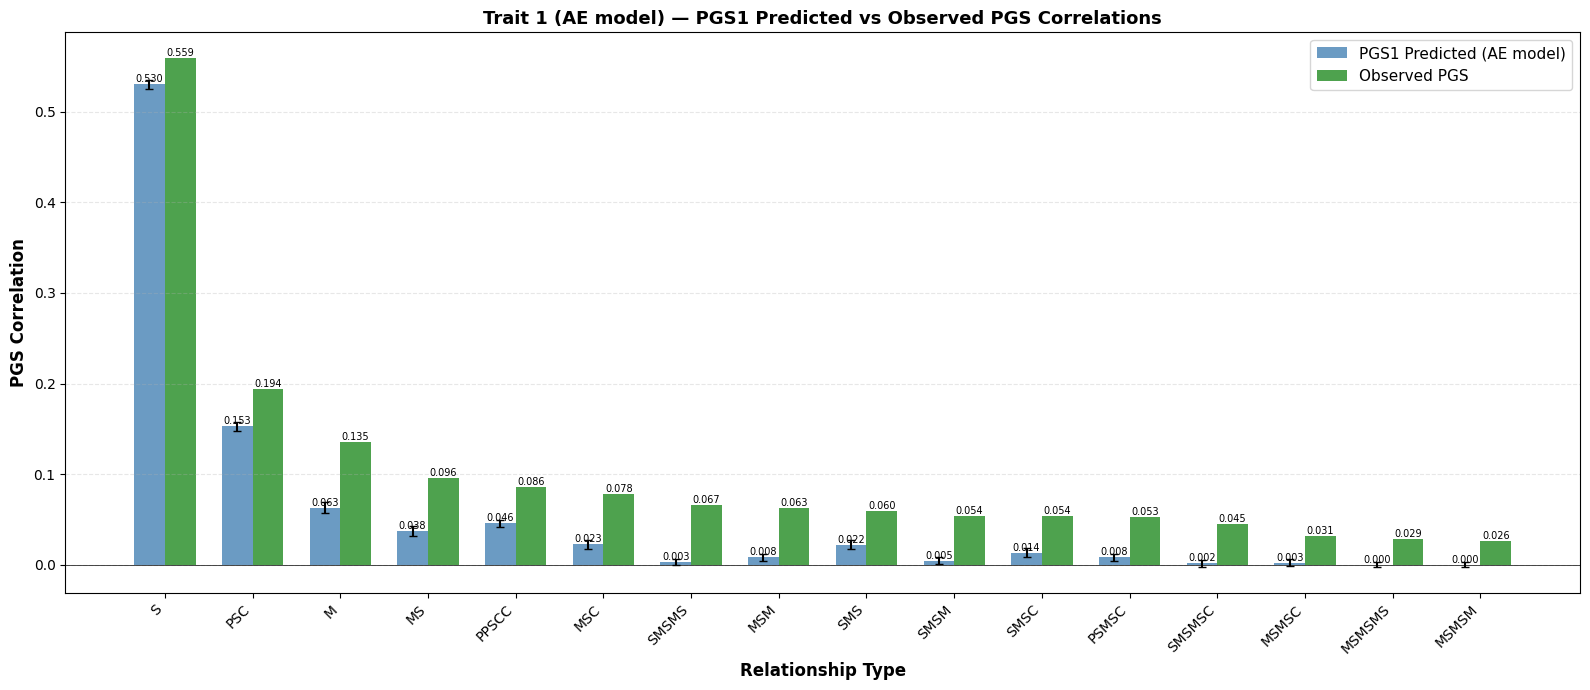


Prediction error — Trait 1 PGS1 vs Observed PGS:
  PGS1 vs Obs_PGS  MAE=0.0446  RMSE=0.0465  Bias=-0.0446  r=0.9948


In [2]:
def add_bar_labels(ax, bars):
    """Add value labels on top of bars, skipping NaN."""
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h,
                    f"{h:.3f}", ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=7)

def error_summary(label, pred_col, obs_col, df):
    """Print MAE, RMSE, bias and r(pred, obs)."""
    valid = df.dropna(subset=[pred_col, obs_col])
    if len(valid) < 2:
        print(f"  {label}: insufficient data")
        return
    diff = valid[pred_col] - valid[obs_col]
    mae  = diff.abs().mean()
    rmse = np.sqrt((diff ** 2).mean())
    bias = diff.mean()
    r    = valid[[pred_col, obs_col]].corr().iloc[0, 1]
    print(f"  {label}  MAE={mae:.4f}  RMSE={rmse:.4f}  Bias={bias:.4f}  r={r:.4f}")

# ── Trait 1 — PGS1 bar chart ───────────────────────────────────────────────
rel_types = pivoted["RelType"].values
x = np.arange(len(rel_types))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width / 2, pivoted["Correlation_Mean_PGS1"], width,
               yerr=pivoted["Correlation_SD_PGS1"], capsize=3,
               label="PGS1 Predicted (AE model)", alpha=0.8, color="steelblue")
bars2 = ax.bar(x + width / 2, pivoted["Obs_PGS"], width,
               label="Observed PGS", alpha=0.8, color="forestgreen")

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

ax.set_xlabel("Relationship Type", fontsize=12, fontweight="bold")
ax.set_ylabel("PGS Correlation", fontsize=12, fontweight="bold")
ax.set_title("Trait 1 (AE model) — PGS1 Predicted vs Observed PGS Correlations",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rel_types, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nPrediction error — Trait 1 PGS1 vs Observed PGS:")
error_summary("PGS1 vs Obs_PGS", "Correlation_Mean_PGS1", "Obs_PGS", pivoted)

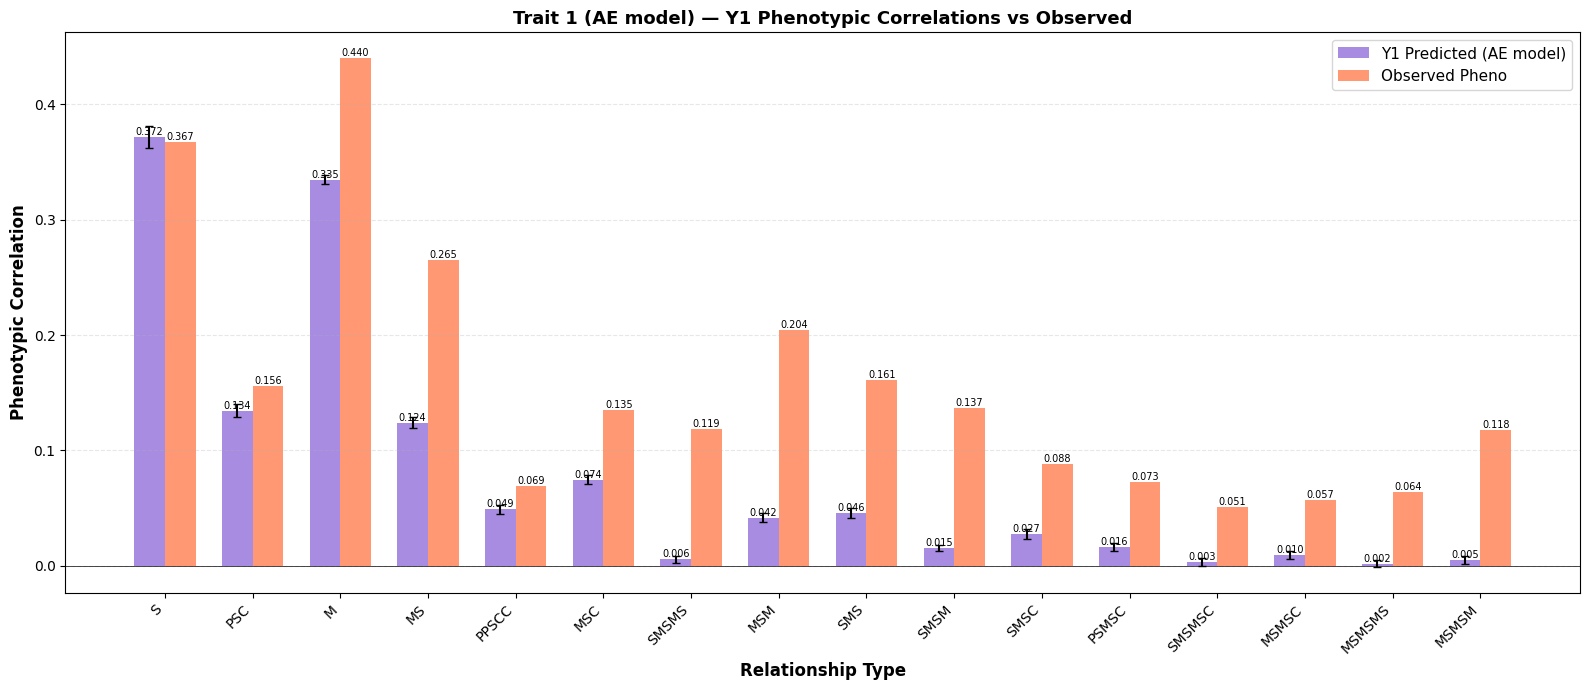


Prediction error — Trait 1 Y1 vs Observed Pheno:
  Y1 vs Obs_Pheno  MAE=0.0784  RMSE=0.0905  Bias=-0.0779  r=0.9124


In [3]:
# ── Trait 1 — Y1 phenotypic bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width / 2, pivoted["Correlation_Mean_Y1"], width,
               yerr=pivoted["Correlation_SD_Y1"], capsize=3,
               label="Y1 Predicted (AE model)", alpha=0.8, color="mediumpurple")
bars2 = ax.bar(x + width / 2, pivoted["Obs_Pheno"], width,
               label="Observed Pheno", alpha=0.8, color="coral")

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

ax.set_xlabel("Relationship Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Phenotypic Correlation", fontsize=12, fontweight="bold")
ax.set_title("Trait 1 (AE model) — Y1 Phenotypic Correlations vs Observed",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rel_types, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nPrediction error — Trait 1 Y1 vs Observed Pheno:")
error_summary("Y1 vs Obs_Pheno", "Correlation_Mean_Y1", "Obs_Pheno", pivoted)

## Trait 2 — Direct AM, AFE Model (with vertical transmission and social homogamy)

Parameters: `prop_h2_latent2=0.7082`, `vg2=0.2708`, `am22=0.3288`, `f22=0.0111`, `s22=0.2600`

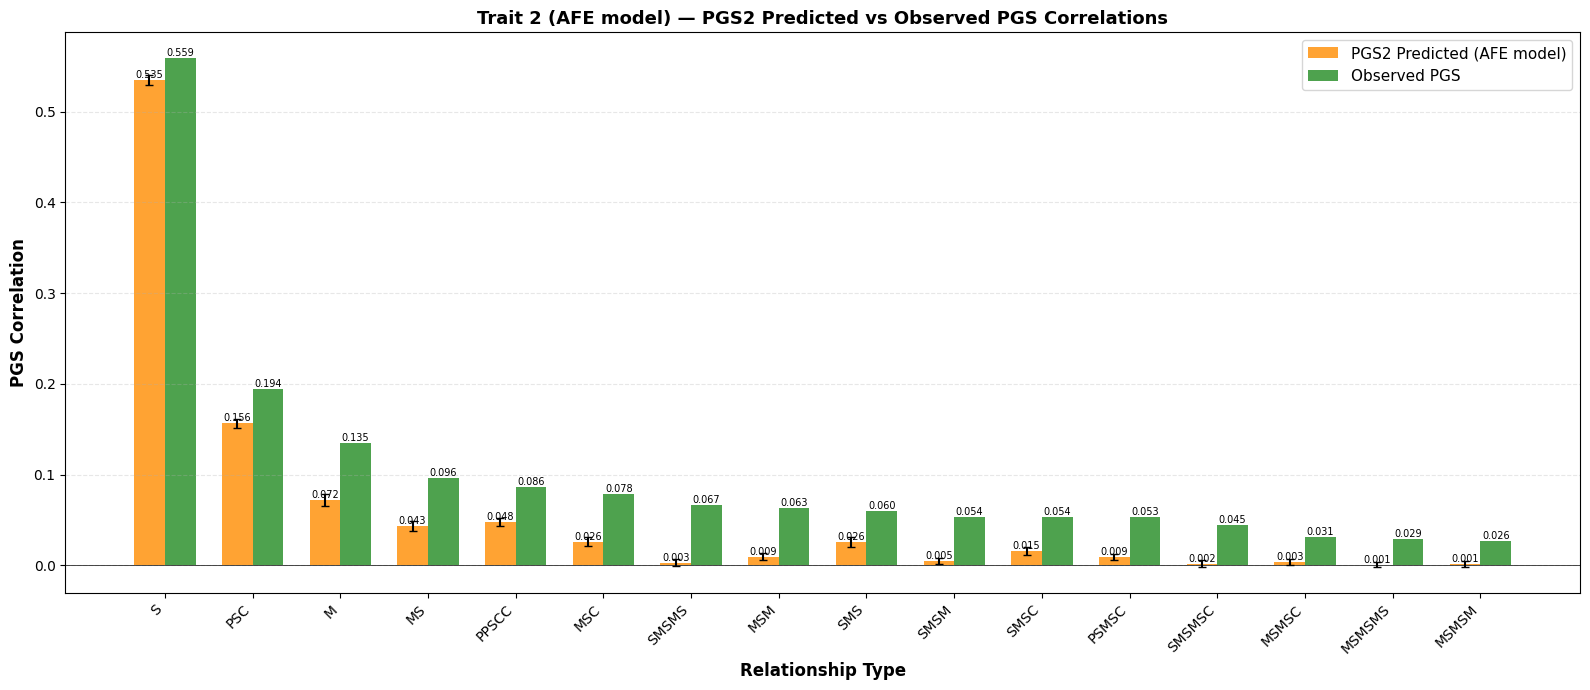


Prediction error — Trait 2 PGS2 vs Observed PGS:
  PGS2 vs Obs_PGS  MAE=0.0422  RMSE=0.0440  Bias=-0.0422  r=0.9957


In [4]:
# ── Trait 2 — PGS2 bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width / 2, pivoted["Correlation_Mean_PGS2"], width,
               yerr=pivoted["Correlation_SD_PGS2"], capsize=3,
               label="PGS2 Predicted (AFE model)", alpha=0.8, color="darkorange")
bars2 = ax.bar(x + width / 2, pivoted["Obs_PGS"], width,
               label="Observed PGS", alpha=0.8, color="forestgreen")

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

ax.set_xlabel("Relationship Type", fontsize=12, fontweight="bold")
ax.set_ylabel("PGS Correlation", fontsize=12, fontweight="bold")
ax.set_title("Trait 2 (AFE model) — PGS2 Predicted vs Observed PGS Correlations",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rel_types, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nPrediction error — Trait 2 PGS2 vs Observed PGS:")
error_summary("PGS2 vs Obs_PGS", "Correlation_Mean_PGS2", "Obs_PGS", pivoted)

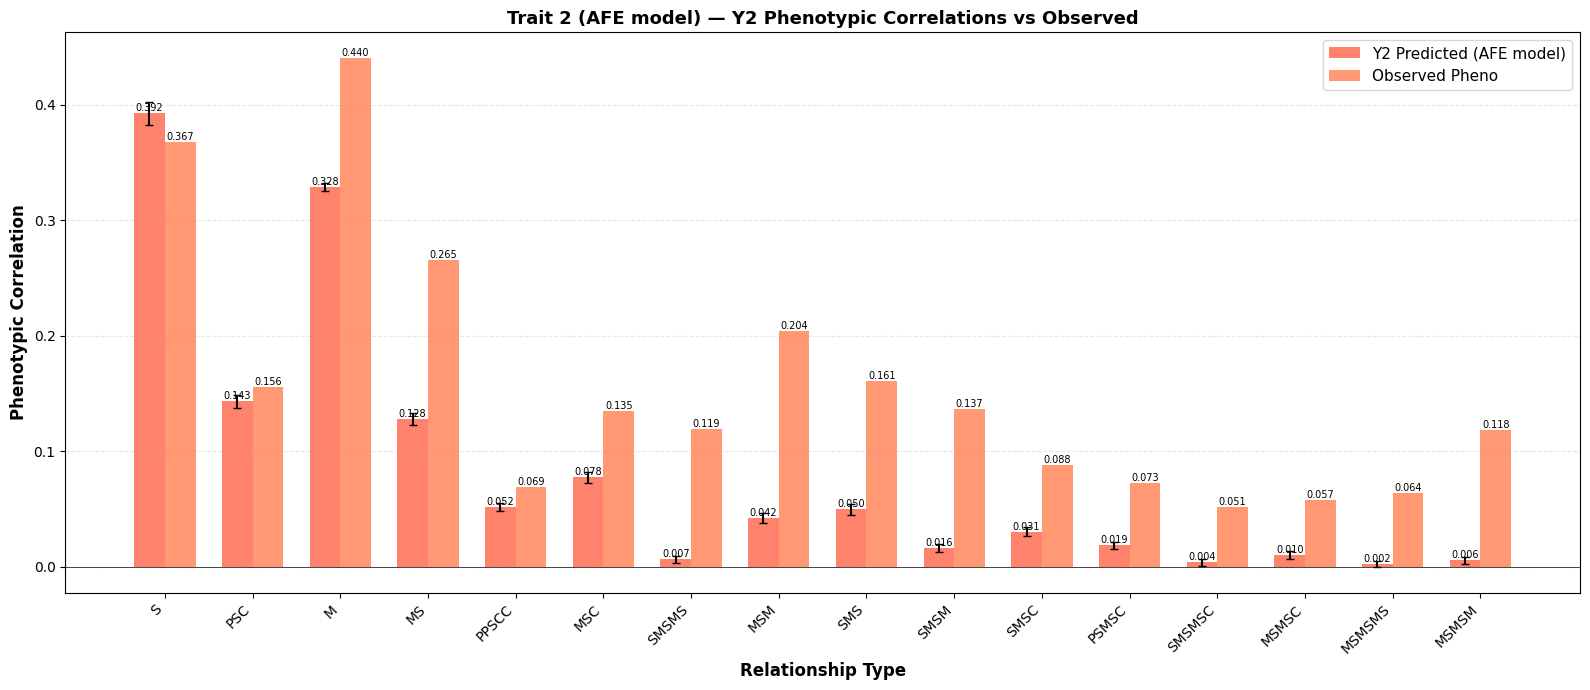


Prediction error — Trait 2 Y2 vs Observed Pheno:
  Y2 vs Obs_Pheno  MAE=0.0780  RMSE=0.0897  Bias=-0.0749  r=0.9029


In [5]:
# ── Trait 2 — Y2 phenotypic bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width / 2, pivoted["Correlation_Mean_Y2"], width,
               yerr=pivoted["Correlation_SD_Y2"], capsize=3,
               label="Y2 Predicted (AFE model)", alpha=0.8, color="tomato")
bars2 = ax.bar(x + width / 2, pivoted["Obs_Pheno"], width,
               label="Observed Pheno", alpha=0.8, color="coral")

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

ax.set_xlabel("Relationship Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Phenotypic Correlation", fontsize=12, fontweight="bold")
ax.set_title("Trait 2 (AFE model) — Y2 Phenotypic Correlations vs Observed",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rel_types, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nPrediction error — Trait 2 Y2 vs Observed Pheno:")
error_summary("Y2 vs Obs_Pheno", "Correlation_Mean_Y2", "Obs_Pheno", pivoted)

## Combined Summary — Both Conditions vs Observed

Scatter plots (predicted vs observed) and a side-by-side bar chart for PGS and phenotypic correlations across both traits.

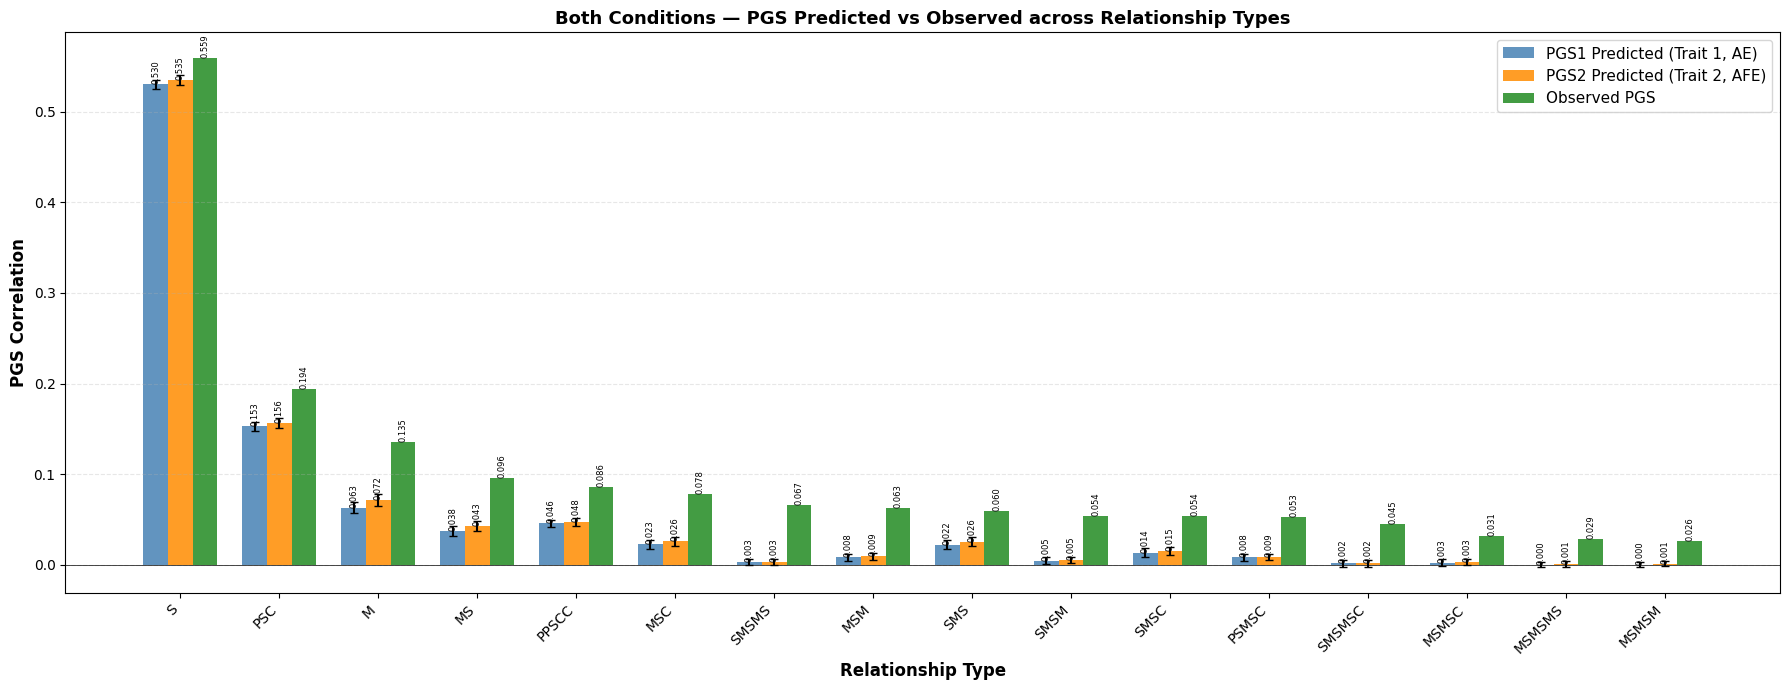

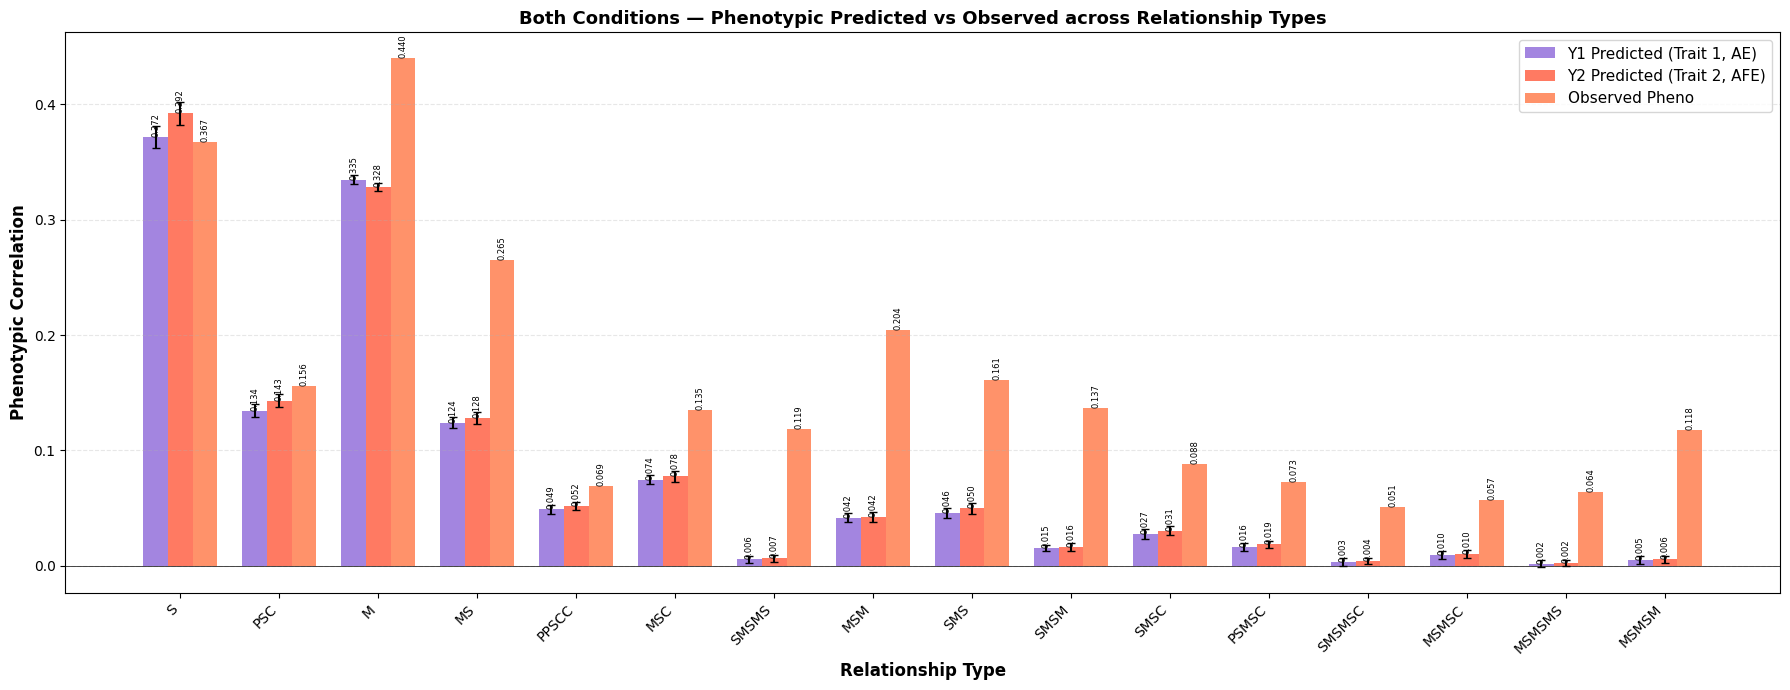

In [6]:
# ── Combined PGS bar chart: PGS1, PGS2, Observed ─────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
w = 0.25

bars1 = ax.bar(x - w, pivoted["Correlation_Mean_PGS1"], w,
               yerr=pivoted["Correlation_SD_PGS1"], capsize=3,
               label="PGS1 Predicted (Trait 1, AE)", alpha=0.85, color="steelblue")
bars2 = ax.bar(x,     pivoted["Correlation_Mean_PGS2"], w,
               yerr=pivoted["Correlation_SD_PGS2"], capsize=3,
               label="PGS2 Predicted (Trait 2, AFE)", alpha=0.85, color="darkorange")
bars3 = ax.bar(x + w, pivoted["Obs_PGS"], w,
               label="Observed PGS", alpha=0.85, color="forestgreen")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h,
                    f"{h:.3f}", ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=6, rotation=90)

ax.set_xlabel("Relationship Type", fontsize=12, fontweight="bold")
ax.set_ylabel("PGS Correlation", fontsize=12, fontweight="bold")
ax.set_title("Both Conditions — PGS Predicted vs Observed across Relationship Types",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rel_types, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# ── Combined Pheno bar chart: Y1, Y2, Observed ────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
bars1 = ax.bar(x - w, pivoted["Correlation_Mean_Y1"], w,
               yerr=pivoted["Correlation_SD_Y1"], capsize=3,
               label="Y1 Predicted (Trait 1, AE)", alpha=0.85, color="mediumpurple")
bars2 = ax.bar(x,     pivoted["Correlation_Mean_Y2"], w,
               yerr=pivoted["Correlation_SD_Y2"], capsize=3,
               label="Y2 Predicted (Trait 2, AFE)", alpha=0.85, color="tomato")
bars3 = ax.bar(x + w, pivoted["Obs_Pheno"], w,
               label="Observed Pheno", alpha=0.85, color="coral")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2., h,
                    f"{h:.3f}", ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=6, rotation=90)

ax.set_xlabel("Relationship Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Phenotypic Correlation", fontsize=12, fontweight="bold")
ax.set_title("Both Conditions — Phenotypic Predicted vs Observed across Relationship Types",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rel_types, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

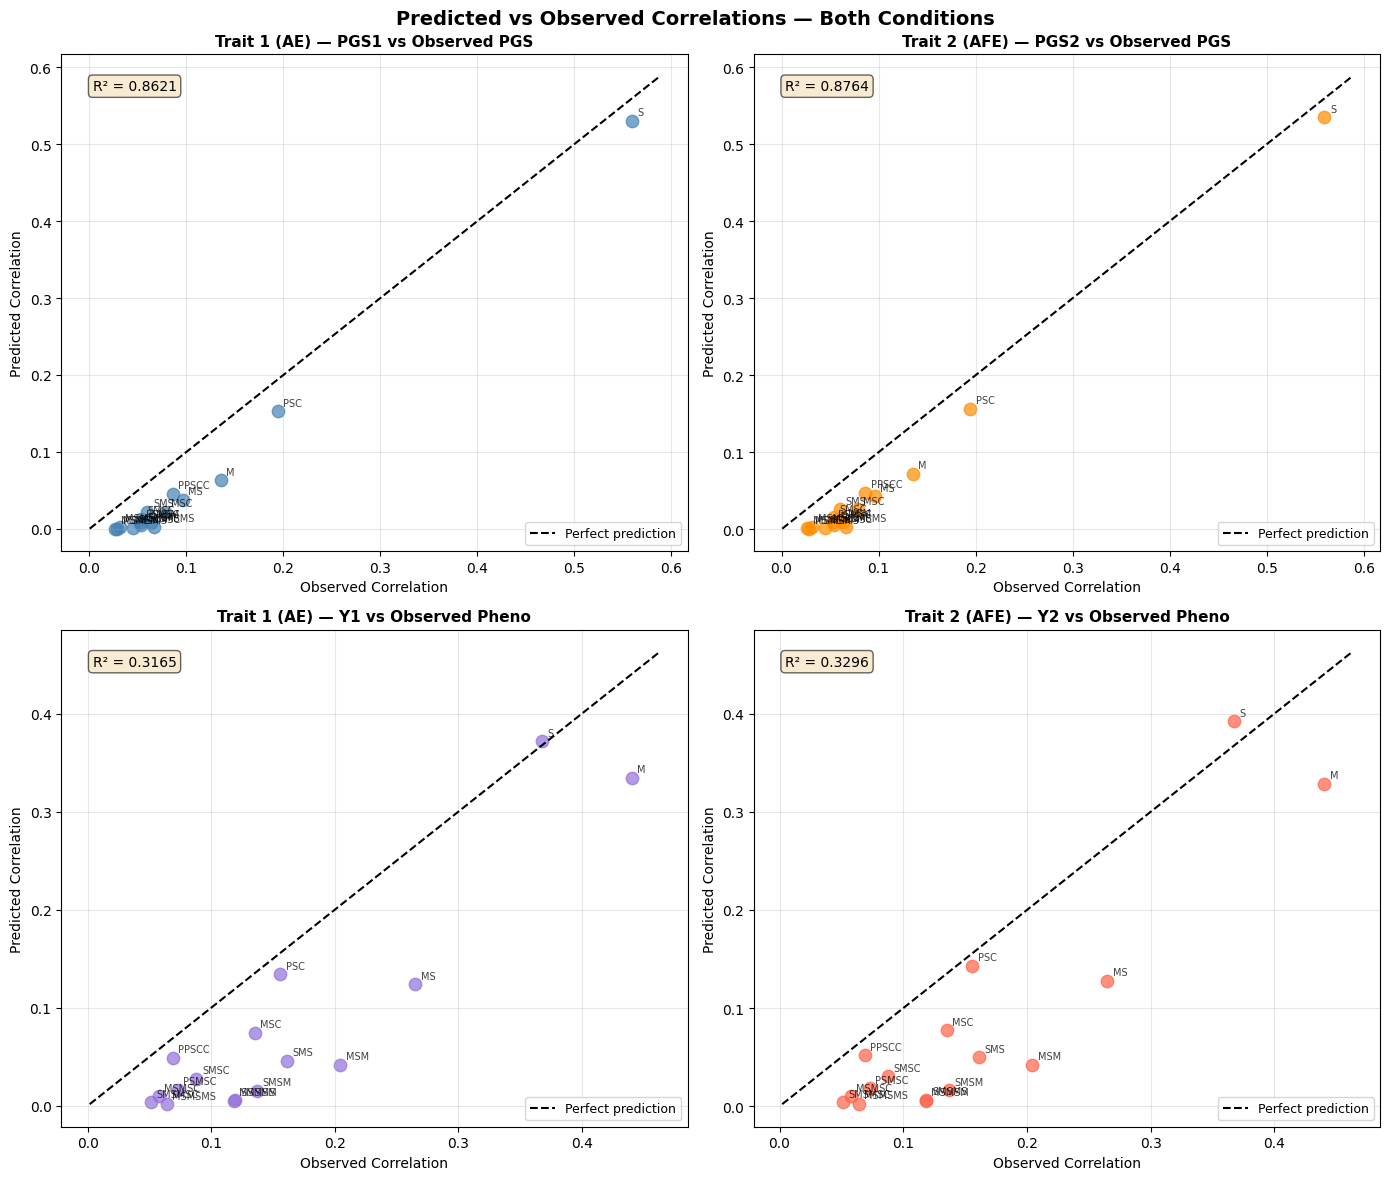


PREDICTION ERROR SUMMARY
  Trait 1 (AE)   PGS1 vs Observed PGS    MAE=0.0446  RMSE=0.0465  Bias=-0.0446  r=0.9948
  Trait 2 (AFE)  PGS2 vs Observed PGS    MAE=0.0422  RMSE=0.0440  Bias=-0.0422  r=0.9957
  Trait 1 (AE)   Y1   vs Observed Pheno  MAE=0.0784  RMSE=0.0905  Bias=-0.0779  r=0.9124
  Trait 2 (AFE)  Y2   vs Observed Pheno  MAE=0.0780  RMSE=0.0897  Bias=-0.0749  r=0.9029


In [7]:
# ── Scatter plots: predicted vs observed for both traits ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Predicted vs Observed Correlations — Both Conditions", fontsize=14, fontweight="bold")

scatter_specs = [
    (axes[0, 0], "Correlation_Mean_PGS1", "Obs_PGS",
     "Trait 1 (AE) — PGS1 vs Observed PGS", "steelblue"),
    (axes[0, 1], "Correlation_Mean_PGS2", "Obs_PGS",
     "Trait 2 (AFE) — PGS2 vs Observed PGS", "darkorange"),
    (axes[1, 0], "Correlation_Mean_Y1", "Obs_Pheno",
     "Trait 1 (AE) — Y1 vs Observed Pheno", "mediumpurple"),
    (axes[1, 1], "Correlation_Mean_Y2", "Obs_Pheno",
     "Trait 2 (AFE) — Y2 vs Observed Pheno", "tomato"),
]

for ax, pred_col, obs_col, title, color in scatter_specs:
    valid = pivoted.dropna(subset=[pred_col, obs_col])
    if len(valid) < 2:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(title, fontsize=11, fontweight="bold")
        continue

    ax.scatter(valid[obs_col], valid[pred_col], s=80, alpha=0.7, color=color)

    # Identity line
    lo = min(valid[obs_col].min(), valid[pred_col].min()) * 0.95
    hi = max(valid[obs_col].max(), valid[pred_col].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.5, label="Perfect prediction")

    # Labels
    for _, row in valid.iterrows():
        ax.annotate(row["RelType"],
                    (row[obs_col], row[pred_col]),
                    fontsize=7, alpha=0.75,
                    xytext=(4, 4), textcoords="offset points")

    # R²
    from sklearn.metrics import r2_score
    r2 = r2_score(valid[obs_col], valid[pred_col])
    ax.text(0.05, 0.95, f"R² = {r2:.4f}", transform=ax.transAxes,
            fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

    ax.set_xlabel("Observed Correlation", fontsize=10)
    ax.set_ylabel("Predicted Correlation", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary error table ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PREDICTION ERROR SUMMARY")
print("=" * 70)
for pred_col, obs_col, label in [
    ("Correlation_Mean_PGS1", "Obs_PGS",   "Trait 1 (AE)   PGS1 vs Observed PGS  "),
    ("Correlation_Mean_PGS2", "Obs_PGS",   "Trait 2 (AFE)  PGS2 vs Observed PGS  "),
    ("Correlation_Mean_Y1",   "Obs_Pheno", "Trait 1 (AE)   Y1   vs Observed Pheno"),
    ("Correlation_Mean_Y2",   "Obs_Pheno", "Trait 2 (AFE)  Y2   vs Observed Pheno"),
]:
    error_summary(label, pred_col, obs_col, pivoted)